In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

In [3]:
def clean (filepath): 
    df = pd.read_csv(filepath , sep=';')
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').set_index('Date')
    return df['Price']

In [4]:
prices = clean("C:/Users/azert/Desktop/JPM.csv")
returns = np.log(prices / prices.shift(1)).dropna()

print(f"Loaded {len(returns)} days of returns")
print(returns.tail())

Loaded 1254 days of returns
Date
2026-08-17   -0.005195
2026-08-18    0.006324
2026-08-19   -0.016627
2026-08-20   -0.016112
2026-08-21    0.000085
Name: Price, dtype: float64


In [5]:
##Squared returns as a volatility proxy


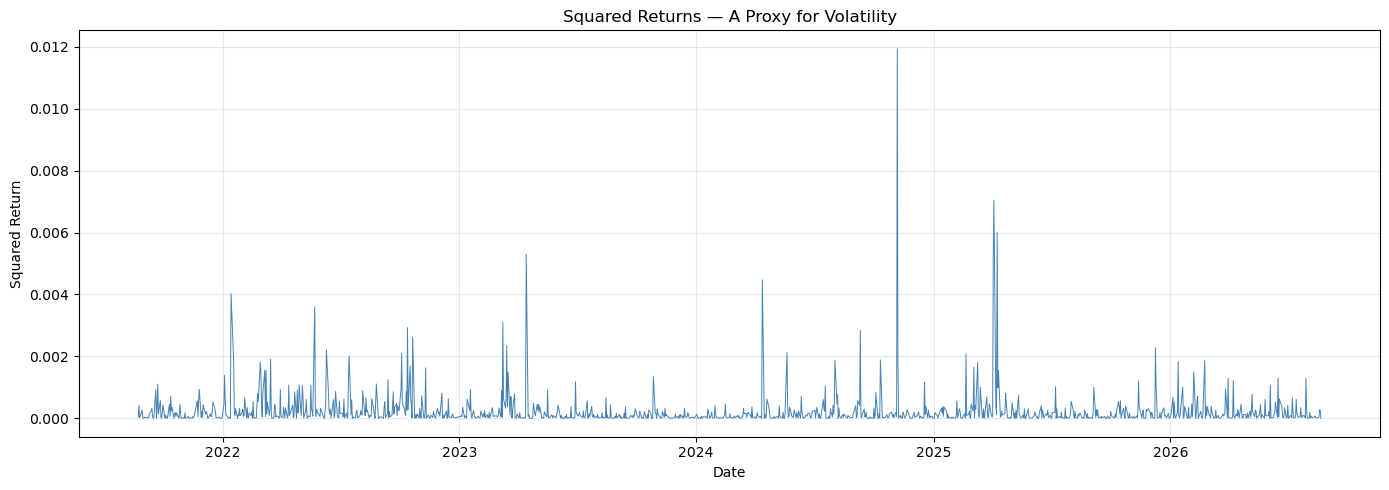

In [5]:
squared_returns = returns **2
plt.figure(figsize=(14,5))
plt.plot(squared_returns.index,squared_returns.values,color='steelblue',linewidth=0.7)
plt.title('Squared Returns — A Proxy for Volatility')
plt.xlabel('Date')
plt.ylabel('Squared Return')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('squared_returns.png', dpi=150)
plt.show()

In [13]:
##Rolling volatility vs static volatility

In [6]:
rolling_vol_30 = returns.rolling(window=30).std()*np.sqrt(252)
static_vol = returns.std()*np.sqrt(252)

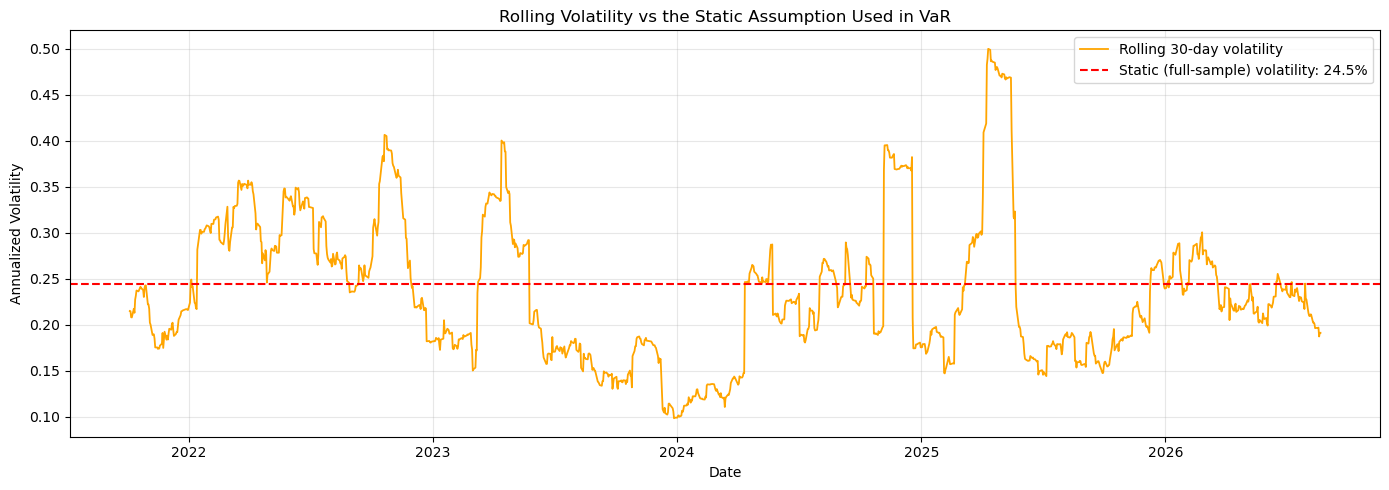

Static volatility (what Parametric VaR used): 24.48%
Rolling volatility range: 9.86% to 50.01%


In [7]:
plt.figure(figsize=(14,5))
plt.plot(rolling_vol_30.index,rolling_vol_30.values,color='orange', linewidth=1.3, label='Rolling 30-day volatility')
plt.axhline(static_vol, color='red', linestyle='--', linewidth=1.5, label=f'Static (full-sample) volatility: {static_vol*100:.1f}%')
plt.title('Rolling Volatility vs the Static Assumption Used in VaR')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rolling_vs_static_vol.png', dpi=150)
plt.show()

print(f"Static volatility (what Parametric VaR used): {static_vol*100:.2f}%")
print(f"Rolling volatility range: {rolling_vol_30.min()*100:.2f}% to {rolling_vol_30.max()*100:.2f}%")

In [8]:
from statsmodels.graphics.tsaplots import plot_acf

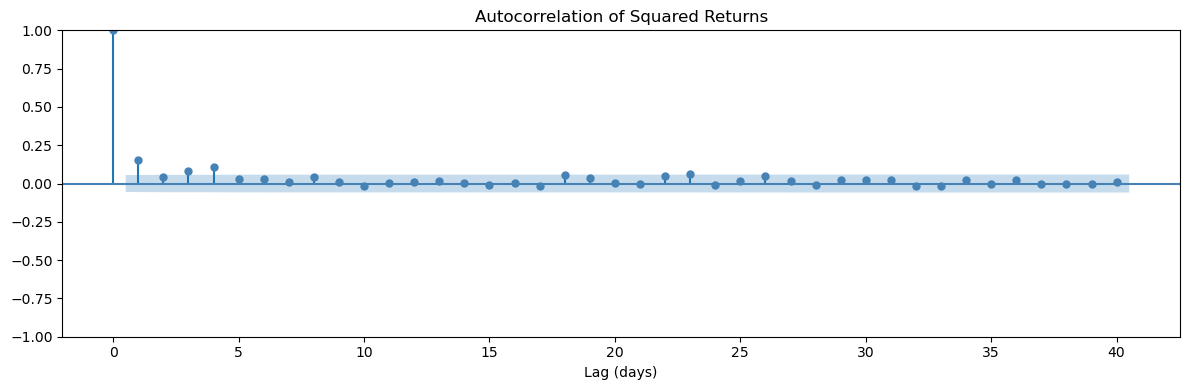

In [9]:
fig , ax = plt.subplots(figsize=(12,4))
plot_acf(squared_returns.dropna(),lags=40,ax=ax,color = 'steelblue')
plt.title('Autocorrelation of Squared Returns')
plt.xlabel('Lag (days)')
plt.tight_layout()
plt.savefig('acf_squared_returns.png', dpi=150)
plt.show()

In [10]:
from statsmodels.stats.diagnostic import het_arch
lm_stat, lm_pvalue,f_stat,f_pvalue = het_arch(returns.dropna())
print("=== ARCH-LM Test (Engle 1982) ===")
print(f"LM Statistic:  {lm_stat:.4f}")
print(f"p-value:       {lm_pvalue:.6f}")
print()

if lm_pvalue < 0.05:
    print("ARCH effects ARE present (p < 0.05)")
    print("→ Volatility clustering is statistically significant")
    print("→ GARCH modeling is justified for this series")
else:
    print("No significant ARCH effects detected")
print(lm_pvalue)

=== ARCH-LM Test (Engle 1982) ===
LM Statistic:  48.5088
p-value:       0.000001

ARCH effects ARE present (p < 0.05)
→ Volatility clustering is statistically significant
→ GARCH modeling is justified for this series
5.010445643969402e-07


In [13]:
pip install arch 

Note: you may need to restart the kernel to use updated packages.


In [11]:
from arch import arch_model
returns_prct = returns*100
model_arch= arch_model(returns_prct,vol='ARCH',p=1)
result_arch = model_arch.fit(disp='off')
print(result_arch.summary())

                      Constant Mean - ARCH Model Results                      
Dep. Variable:                  Price   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -2303.50
Distribution:                  Normal   AIC:                           4613.01
Method:            Maximum Likelihood   BIC:                           4628.41
                                        No. Observations:                 1254
Date:                Mon, Sep 21 2026   Df Residuals:                     1253
Time:                        22:38:46   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0838  4.189e-02      2.000  4.545e-02 [1.698e-0

In [12]:
omega_arch = result_arch.params['omega']
alpha_arch = result_arch.params['alpha[1]']
print(f"omega (ω): {omega_arch:.6f}")
print(f"alpha (α): {alpha_arch:.6f}")
print()
print(f"Formula: σ²_t = {omega_arch:.4f} + {alpha_arch:.4f} × ε²_(t-1)")
print()
print("Interpretation: today's variance depends ONLY on")
print("yesterday's squared shock — no memory beyond 1 day.")

omega (ω): 2.068179
alpha (α): 0.124835

Formula: σ²_t = 2.0682 + 0.1248 × ε²_(t-1)

Interpretation: today's variance depends ONLY on
yesterday's squared shock — no memory beyond 1 day.


In [16]:
## garch 1.1

In [13]:
model_garch = arch_model(returns_prct, vol='GARCH',p=1,q=1)
result_garch =model_garch.fit(disp='off')
print(result_garch.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  Price   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2288.50
Distribution:                  Normal   AIC:                           4585.01
Method:            Maximum Likelihood   BIC:                           4605.54
                                        No. Observations:                 1254
Date:                Mon, Sep 21 2026   Df Residuals:                     1253
Time:                        22:38:51   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0992  4.285e-02      2.315  2.060e-02 [1.523e-0

In [14]:
omega = result_garch.params['omega']
alpha = result_garch.params['alpha[1]']
beta  = result_garch.params['beta[1]']

print(f"omega (ω): {omega:.6f}")
print(f"alpha (α): {alpha:.6f}")
print(f"beta (β):  {beta:.6f}")
print()
print(f"Formula: σ²_t = {omega:.4f} + {alpha:.4f}×ε²_(t-1) + {beta:.4f}×σ²_(t-1)")
print()

persistence = alpha + beta
print(f"Persistence (α+β): {persistence:.4f}")

if persistence < 1:
    print("✓ Model is stationary (α+β < 1) — valid GARCH model")
else:
    print("⚠ α+β ≥ 1 — model is not stationary, check specification")

half_life = np.log(0.5) / np.log(persistence)
print(f"Volatility shock half-life: {half_life:.1f} days")

omega (ω): 0.498867
alpha (α): 0.097231
beta (β):  0.691368

Formula: σ²_t = 0.4989 + 0.0972×ε²_(t-1) + 0.6914×σ²_(t-1)

Persistence (α+β): 0.7886
✓ Model is stationary (α+β < 1) — valid GARCH model
Volatility shock half-life: 2.9 days


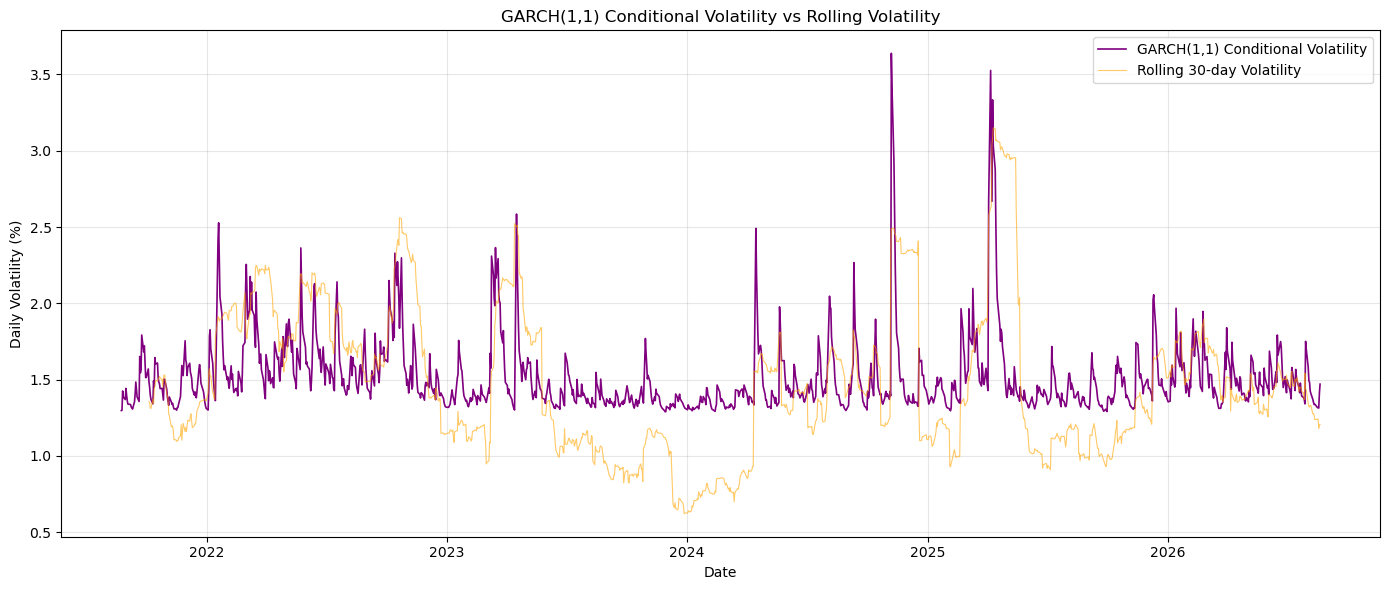

In [15]:
conditional_vol = result_garch.conditional_volatility  # in % terms

plt.figure(figsize=(14, 6))
plt.plot(conditional_vol.index, conditional_vol.values, 
         color='purple', linewidth=1.2, label='GARCH(1,1) Conditional Volatility')
plt.plot(rolling_vol_30.index, (rolling_vol_30.values/np.sqrt(252))*100, 
         color='orange', linewidth=0.8, alpha=0.6, label='Rolling 30-day Volatility')
plt.title('GARCH(1,1) Conditional Volatility vs Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Daily Volatility (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('garch_conditional_volatility.png', dpi=150)
plt.show()

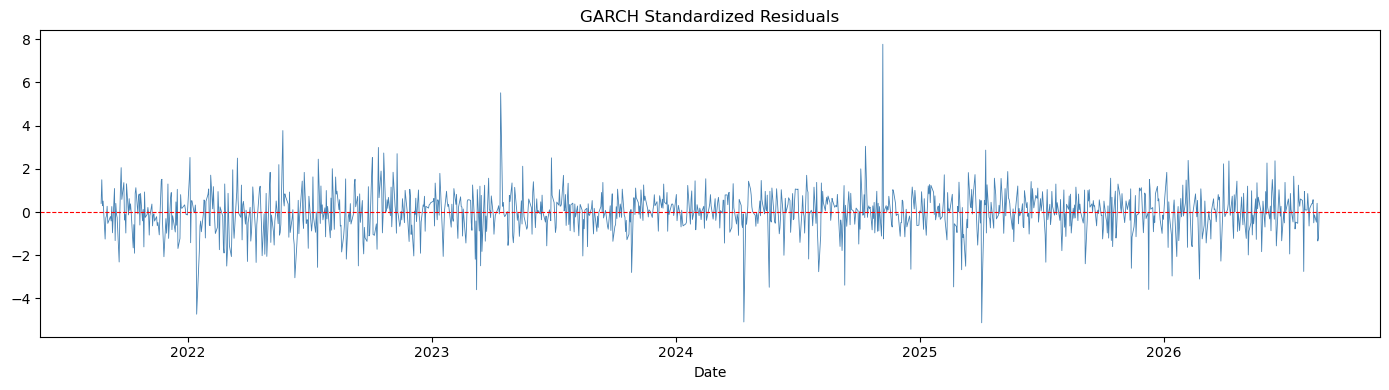

Mean of standardized residuals: -0.0215 (should be ≈ 0)
Std of standardized residuals:  1.0000 (should be ≈ 1)


In [18]:
std_resid = result_garch.std_resid
plt.figure(figsize=(14, 4))
plt.plot(std_resid.index, std_resid.values, color='steelblue', linewidth=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.title('GARCH Standardized Residuals')
plt.xlabel('Date')
plt.tight_layout()
plt.savefig('garch_std_residuals.png', dpi=150)
plt.show()

print(f"Mean of standardized residuals: {std_resid.mean():.4f} (should be ≈ 0)")
print(f"Std of standardized residuals:  {std_resid.std():.4f} (should be ≈ 1)")

In [19]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_levels = acorr_ljungbox(std_resid.dropna(), lags=[10], return_df=True)
lb_squared = acorr_ljungbox((std_resid.dropna())**2, lags=[10], return_df=True)

print("=== Ljung-Box on standardized residuals ===")
print(lb_levels)
print()
print("=== Ljung-Box on SQUARED standardized residuals ===")
print(lb_squared)
print()
print("If p-value > 0.05 in both tests: no remaining autocorrelation")
print("→ GARCH(1,1) successfully captured the volatility dynamics")

=== Ljung-Box on standardized residuals ===
    lb_stat  lb_pvalue
10  6.32081   0.787629

=== Ljung-Box on SQUARED standardized residuals ===
     lb_stat  lb_pvalue
10  4.429128   0.925919

If p-value > 0.05 in both tests: no remaining autocorrelation
→ GARCH(1,1) successfully captured the volatility dynamics


In [21]:
orders_to_test = [(1,1), (1,2), (2,1), (2,2)]

print(f"{'Model':<15}{'AIC':>12}{'BIC':>12}")
print("-" * 39)

for p, q in orders_to_test:
    m = arch_model(returns_prct, vol='GARCH', p=p, q=q)
    r = m.fit(disp='off')
    print(f"GARCH({p},{q}){'':<5}{r.aic:>12.2f}{r.bic:>12.2f}")

print()
print("Lower AIC/BIC = better fit (with penalty for complexity)")

Model                   AIC         BIC
---------------------------------------
GARCH(1,1)          4585.01     4605.54
GARCH(1,2)          4587.01     4612.68
GARCH(2,1)          4586.97     4612.64
GARCH(2,2)          4585.05     4615.86

Lower AIC/BIC = better fit (with penalty for complexity)


In [22]:
forecast = result_garch.forecast(horizon=10)
forecast_variance = forecast.variance.values[-1, :]
forecast_vol = np.sqrt(forecast_variance)

print("=== 10-Day Ahead Volatility Forecast ===")
for i, vol in enumerate(forecast_vol, 1):
    print(f"Day +{i}: {vol:.4f}% daily volatility")

=== 10-Day Ahead Volatility Forecast ===
Day +1: 1.4121% daily volatility
Day +2: 1.4393% daily volatility
Day +3: 1.4603% daily volatility
Day +4: 1.4766% daily volatility
Day +5: 1.4894% daily volatility
Day +6: 1.4994% daily volatility
Day +7: 1.5073% daily volatility
Day +8: 1.5134% daily volatility
Day +9: 1.5183% daily volatility
Day +10: 1.5221% daily volatility


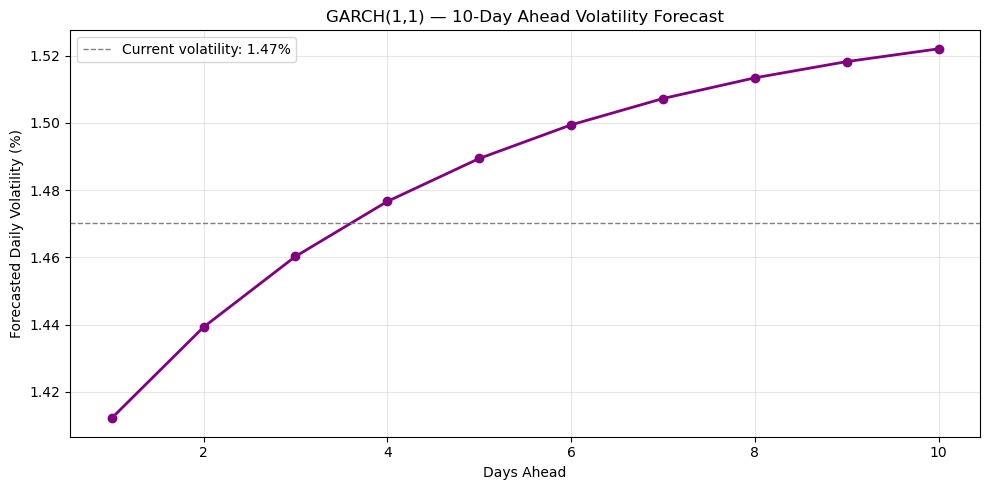

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), forecast_vol, marker='o', 
         color='purple', linewidth=2, markersize=6)
plt.axhline(conditional_vol.iloc[-1], color='gray', linestyle='--',
            linewidth=1, label=f'Current volatility: {conditional_vol.iloc[-1]:.2f}%')
plt.title('GARCH(1,1) — 10-Day Ahead Volatility Forecast')
plt.xlabel('Days Ahead')
plt.ylabel('Forecasted Daily Volatility (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('garch_forecast.png', dpi=150)
plt.show()

In [24]:
# Preview: how tomorrow's GARCH forecast feeds into tomorrow's VaR
tomorrow_vol_pct = forecast_vol[0] / 100  # convert back to decimal
z_99 = 2.326
portfolio_value = 1_000_000

garch_var_tomorrow = abs(returns.mean() - z_99 * tomorrow_vol_pct) * portfolio_value

print(f"Tomorrow's forecasted volatility: {tomorrow_vol_pct*100:.3f}%")
print(f"Tomorrow's GARCH-based 99% VaR:   {garch_var_tomorrow:,.0f} MAD")
print()
print(f"Compare to your STATIC Parametric VaR from the VaR project:")
print(f"(same formula, but using the fixed full-sample σ instead)")

Tomorrow's forecasted volatility: 1.412%
Tomorrow's GARCH-based 99% VaR:   32,202 MAD

Compare to your STATIC Parametric VaR from the VaR project:
(same formula, but using the fixed full-sample σ instead)


In [26]:
model_egarch = arch_model(returns_prct, vol='EGARCH', p=1, o=1, q=1)
result_egarch = model_egarch.fit(disp='off')

print(result_egarch.summary())

gamma_e = result_egarch.params['gamma[1]']
print(f"\nAsymmetry parameter (γ): {gamma_e:.4f}")

if gamma_e < 0:
    print("Negative γ confirms the leverage effect:")
    print("negative shocks increase volatility MORE than positive shocks")

                     Constant Mean - EGARCH Model Results                     
Dep. Variable:                  Price   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -2266.63
Distribution:                  Normal   AIC:                           4543.26
Method:            Maximum Likelihood   BIC:                           4568.94
                                        No. Observations:                 1254
Date:                Mon, Sep 21 2026   Df Residuals:                     1253
Time:                        22:46:28   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0552  3.907e-02      1.412      0.158 [-2.14

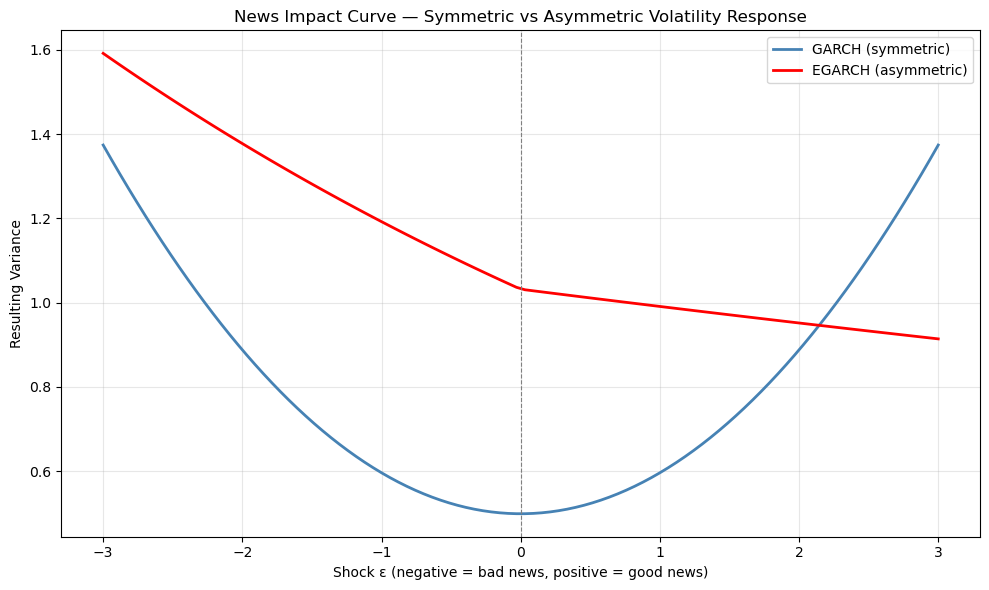

In [27]:
epsilon = np.linspace(-3, 3, 100)

# GARCH: symmetric — same response regardless of sign
garch_nic = omega + alpha * epsilon**2

# EGARCH: asymmetric response
omega_e = result_egarch.params['omega']
alpha_e = result_egarch.params['alpha[1]']
egarch_nic = np.exp(omega_e + alpha_e * np.abs(epsilon) + gamma_e * epsilon)

plt.figure(figsize=(10, 6))
plt.plot(epsilon, garch_nic, color='steelblue', linewidth=2, label='GARCH (symmetric)')
plt.plot(epsilon, egarch_nic, color='red', linewidth=2, label='EGARCH (asymmetric)')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('News Impact Curve — Symmetric vs Asymmetric Volatility Response')
plt.xlabel('Shock ε (negative = bad news, positive = good news)')
plt.ylabel('Resulting Variance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('news_impact_curve.png', dpi=150)
plt.show()

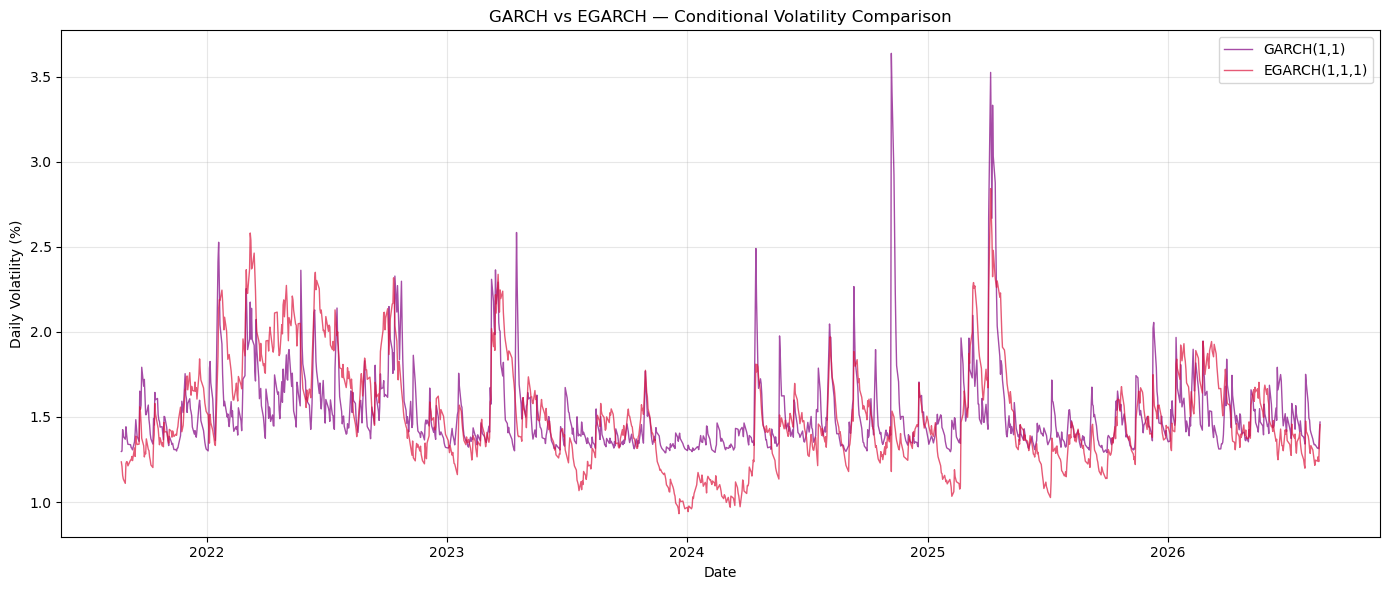

GARCH(1,1)   AIC: 4585.01
EGARCH(1,1,1) AIC: 4543.26


In [28]:
plt.figure(figsize=(14, 6))
plt.plot(result_garch.conditional_volatility.index, 
         result_garch.conditional_volatility, 
         label='GARCH(1,1)', color='purple', alpha=0.7, linewidth=1)
plt.plot(result_egarch.conditional_volatility.index, 
         result_egarch.conditional_volatility, 
         label='EGARCH(1,1,1)', color='crimson', alpha=0.7, linewidth=1)
plt.title('GARCH vs EGARCH — Conditional Volatility Comparison')
plt.xlabel('Date')
plt.ylabel('Daily Volatility (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('garch_vs_egarch.png', dpi=150)
plt.show()

print(f"GARCH(1,1)   AIC: {result_garch.aic:.2f}")
print(f"EGARCH(1,1,1) AIC: {result_egarch.aic:.2f}")
